# Knowledge-based Architecture to Transactional User Sequence and Historical Affinity (KATUSHA)

Knowledge-based hybrid architecture that models transactional user behavior via self-attention over categorical embeddings, explicitly optimizing the trade-off between recommendation relevance and expected transaction value (average recommendations price).

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from tqdm import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

from tecd_retail_recsys.data import DataPreprocessor
from tecd_retail_recsys.utils import get_avg_recs_price, get_item_to_price
from tecd_retail_recsys.metrics import calculate_metrics
from tecd_retail_recsys.models import TopPopular, TopPersonal

from tecd_retail_recsys.models.katusha import (
    transform_frame,
    RecDataset,
    KATUSHA,
    train_one_epoch,
    evaluate,
    predict_scores,
    transform_frame_inference,
    predict_scores_inference
)

from torch.utils.data import DataLoader
import torch
import torch.nn as nn

from copy import deepcopy

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

INFO:faiss.loader:Loading faiss.
INFO:faiss.loader:Successfully loaded faiss.


In [3]:
dp = DataPreprocessor(day_begin=1082, day_end=1308, val_days=20, test_days=20, min_user_interactions=1, min_item_interactions=20)
train_df, val_df, test_df = dp.preprocess()
joined = dp.get_grouped_data(train_df, val_df, test_df)
joined['train_val_interactions'] = joined['train_interactions'] + joined['val_interactions']

Starting data preprocessing...
Loading events from t_ecd_small_partial/dataset/small/retail/events
Loaded 267,043,972 total events
Loading items data from t_ecd_small_partial/dataset/small/retail/items.pq
Loaded 250,171 items with features: ['item_id', 'item_brand_id', 'item_category', 'item_subcategory', 'item_price', 'item_embedding']
Merged item features. Data shape: (267043972, 12)
Filtered to 3,852,145 events with action_type='added_to_cart'
After filtering (min_user_interactions=1, min_item_interactions=20): 3,327,057 events, 84,830 users, 32,095 items
Created mappings: 84830 users, 32095 items
Temporal split - Train: days < 1269 (922,368 events), Val: days 1269-1288 (232,900 events), Test: days >= 1289 (227,959 events)
Users in each part (train, val, test) - 7422


In [4]:
item_to_price = get_item_to_price(dp)
item_price_df = pd.DataFrame({
    "item_id": list(item_to_price.keys()),
    "item_price": list(item_to_price.values()),
})

### Перебор alpha на валидации

In [5]:
X_scored = pd.read_parquet("processed_data/X_scored_katusha.parquet")

In [6]:
# business re-ranking 

def add_business_score(
    df,
    relevance_col="score",
    price_col="item_price",
    alpha=0.15,
):
    df = df.copy()

    price = df[price_col].fillna(df[price_col].median())

    price_score = (
        price - price.min()
    ) / (
        price.max() - price.min() + 1e-8
    )

    df["price_score"] = price_score

    df["business_score"] = (
        (1 - alpha) * df[relevance_col]
        + alpha * df["price_score"]
    )
    # df['business_score'] = df[relevance_col] + alpha * df["price_score"]

    return df


X_business = X_scored.merge(item_price_df, on="item_id", how="left")

val_metrics = {
    'alpha': [],
    'ndcg@100': [],
    'avg_price': []
}

for _alpha in tqdm([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.7, 0.9, 0.95]):
    final_scores = add_business_score(
        X_business,
        relevance_col="score",
        price_col="item_price",
        alpha=_alpha,
    )

    val_business_recs = (
        final_scores.sort_values(by=["user_id", "business_score"], ascending=[True, False])[["user_id", "item_id"]]
        .groupby("user_id", as_index=False).head(100)
        .groupby("user_id", as_index=False).agg(list)
    )

    val_business_recs.rename(columns={"item_id": "katusha_business_val_recs"}, inplace=True)

    katusha_val_business_metrics = calculate_metrics(
        joined.merge(val_business_recs),
        model_preds="katusha_business_val_recs",
        gt_col="val_interactions",
        train_col="train_interactions",
        k_values=[100],
        verbose=False
    )
    avg_recs_price = get_avg_recs_price(joined.merge(val_business_recs), item_to_price, 'katusha_business_val_recs')

    val_metrics['alpha'].append(_alpha)
    val_metrics['ndcg@100'].append(katusha_val_business_metrics['NDCG@100'])
    val_metrics['avg_price'].append(avg_recs_price)

100%|██████████| 11/11 [02:15<00:00, 12.35s/it]


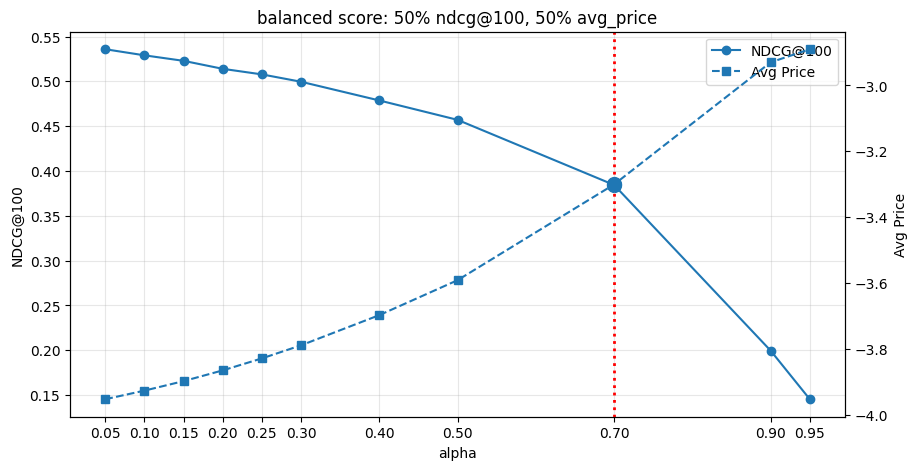

In [ ]:
alpha = np.array(val_metrics["alpha"])
ndcg = np.array(val_metrics["ndcg@100"])
avg_price = np.array(val_metrics["avg_price"])

ndcg_norm = (ndcg - ndcg.min()) / (ndcg.max() - ndcg.min())
price_norm = (avg_price - avg_price.min()) / (avg_price.max() - avg_price.min())
balance_score = 0.5 * ndcg_norm + 0.5 * price_norm

best_idx = np.argmax(balance_score)
best_alpha = alpha[best_idx]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(alpha, ndcg, marker="o", label="NDCG@100")
ax1.set_xlabel("alpha")
ax1.set_xticks(alpha)
ax1.set_ylabel("NDCG@100")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(alpha, avg_price, marker="s", linestyle="--", label="Avg Price")
ax2.set_ylabel("Avg Price")

ax1.axvline(best_alpha, linestyle=":", linewidth=2, color='red')
ax1.scatter(best_alpha, ndcg[best_idx], s=100)
ax2.scatter(best_alpha, avg_price[best_idx], s=100)

plt.title(f"balanced score: 50% ndcg@100, 50% avg_price")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

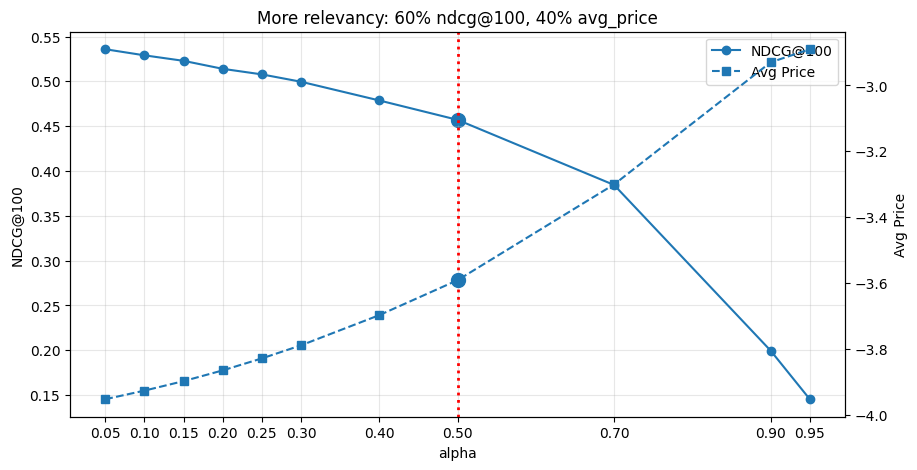

In [22]:
# real situation

alpha = np.array(val_metrics["alpha"])
ndcg = np.array(val_metrics["ndcg@100"])
avg_price = np.array(val_metrics["avg_price"])

ndcg_norm = (ndcg - ndcg.min()) / (ndcg.max() - ndcg.min())
price_norm = (avg_price - avg_price.min()) / (avg_price.max() - avg_price.min())

balance_score = 0.6 * ndcg_norm + 0.4 * price_norm

best_idx = np.argmax(balance_score)
best_alpha = alpha[best_idx]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(alpha, ndcg, marker="o", label="NDCG@100")
ax1.set_xlabel("alpha")
ax1.set_xticks(alpha)
ax1.set_ylabel("NDCG@100")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(alpha, avg_price, marker="s", linestyle="--", label="Avg Price")
ax2.set_ylabel("Avg Price")

ax1.axvline(best_alpha, linestyle=":", linewidth=2, color='red')
ax1.scatter(best_alpha, ndcg[best_idx], s=100)
ax2.scatter(best_alpha, avg_price[best_idx], s=100)

plt.title(f"More relevancy: 60% ndcg@100, 40% avg_price")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

In [23]:
BEST_ALPHA = 0.5

### Инференс лучшей модели на тесте

In [10]:
train_val_scored = pd.read_parquet("processed_data/X_scored_katusha.parquet")
X_business_test = train_val_scored.merge(item_price_df, on="item_id", how="left")

In [24]:
final_scores = add_business_score(
    X_business_test,
    relevance_col="score",
    price_col="item_price",
    alpha=BEST_ALPHA,
)

test_business_recs = (
    final_scores.sort_values(by=["user_id", "business_score"], ascending=[True, False])[["user_id", "item_id"]]
    .groupby("user_id", as_index=False).head(100)
    .groupby("user_id", as_index=False).agg(list)
)

test_business_recs.rename(columns={"item_id": "katusha_business_test_recs"}, inplace=True)

katusha_test_business_metrics = calculate_metrics(
    joined.merge(test_business_recs),
    model_preds="katusha_business_test_recs",
    gt_col="test_interactions",
    train_col="train_val_interactions",
    k_values=[100],
    verbose=True
)

avg_recs_price = get_avg_recs_price(joined.merge(test_business_recs), item_to_price, 'katusha_business_test_recs')
print(f'Средняя цена рекомендаций модели KATUSHA (business targeting): {avg_recs_price:.2f}')

[Metrics debug] resolved gt_col='test_interactions' item_id_index=0
[Metrics debug] ratings_true shape: (159787, 3) ratings_pred shape: (481400, 3)
  ratings_true dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  ratings_pred dtypes: {'user_id': dtype('int64'), 'item_id': dtype('int64')}
  user_id=30 gt_count=30 pred_count=87 overlap=6
  user_id=39 gt_count=17 pred_count=95 overlap=7
  user_id=51 gt_count=10 pred_count=96 overlap=1

At k=100:
  MAP@100       = 0.1089
  NDCG@100      = 0.3922
  Precision@100 = 0.0842
  Recall@100    = 0.2307

Other Metrics:
  MRR                 = 0.2893
  Catalog Coverage    = 0.8459
  Diversity     = 0.9963  [0=same recs for all, 1=unique recs]
  Novelty             = 0.6918
  Serendipity         = 0.0157
Средняя цена рекомендаций модели KATUSHA (business targeting): -3.59
